# Data
## Grid

In [ ]:
# TODO: make independent of sample images

import numpy as np
import pandas as pd
import geopandas as gpd

import xarray as xr
import rioxarray as rxr
import shapely

import matplotlib.pyplot as plt
import re
from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_points_griddata

In [ ]:
ex_empty = rxr.open_rasterio("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/mapbiomas_2010_0000000000-0000000000.tif")
ex_full = rxr.open_rasterio("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/mapbiomas_2010_0000000000-0000046592.tif")

In [ ]:
def get_grid_no(filename):
    return np.int32(re.findall(r"(\d{10})", filename)) / 3328

get_grid_no("mapbiomas_2015_0000006656-0000093184.tif")

array([ 2., 28.])

In [ ]:
boundaries = gpd.read_file("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/boundaries/gadm_410-BRA.geojson",
                           engine = "pyogrio").to_crs(5641)

In [ ]:
min_x = int(np.min(ex_empty.x.to_numpy()))
max_x = int(boundaries.total_bounds[2])
step_x = (30 * len(ex_empty.x))
grid_cells_x = int(((max_x - min_x) // step_x)) + 2
#
min_y = int(boundaries.total_bounds[1])
max_y = int(np.max(ex_empty.y.to_numpy())) + 30
step_y = (30 * len(ex_empty.y))
grid_cells_y = int((max_y - min_y) // step_y) + 2

In [ ]:
xv, yv = np.meshgrid(np.array([min_x + i * step_x for i in range(grid_cells_x)]),
                     np.array([max_y - i * step_y for i in range(grid_cells_y)]))

In [ ]:
# create boxes from grid
boxes = gpd.GeoDataFrame(dict(Row = np.repeat(range(len(xv) - 1), len(xv[0]) - 1),
                              Column = np.tile(range(len(xv[0]) - 1), len(xv) - 1)),
                         geometry = [shapely.box(xv[i, j], yv[i, j] - 30, xv[i, j + 1] - 30, yv[i + 1, j]) for i in range(len(xv) - 1) for j in range(len(xv[0]) - 1)],
                         crs = 5641)

boxes.reset_index(names = "CellID", inplace = True)

boxes[["X", "Y"]] = pd.DataFrame(boxes.exterior.map(lambda x: [min(y) for y in x.xy]).to_list(), columns = ["x", "y"])

boxes["Internal"] = boxes.intersects(boundaries.geometry.iloc[0])

<Axes: >

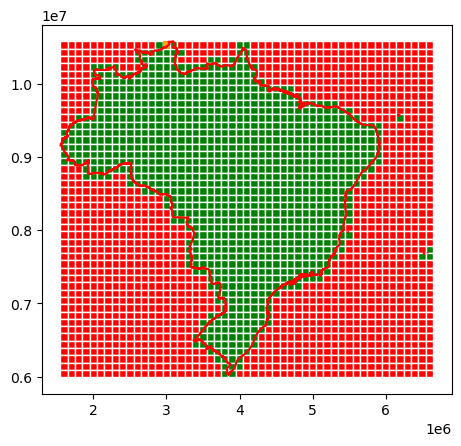

In [ ]:
ax = boxes.plot(edgecolor="white", color = boxes.Internal.map({True: "green", False: "red"}))
boundaries.boundary.plot(ax = ax, color = "red")
boxes.iloc[[14]].plot(ax = ax, color = "orange")

In [ ]:
import sqlite3
conn = sqlite3.connect('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/imagery.db')

# insert data into GridCells table
boxes.drop(columns="geometry").to_sql("GridCells", conn, if_exists = "replace", index = False)

# store geometries externally
boxes[["CellID", "geometry"]].to_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/grid_cells.feather")

---
## Imagery
### Landsat SR C2L2 Imagery

In [ ]:
# description: https://www.usgs.gov/landsat-missions/landsat-collection-2-surface-reflectance
# metadata: https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/media/files/LSDS-1618_Landsat-4-7_C2-L2-ScienceProductGuide-v4.pdf

In [1]:
import xarray as xr
import rioxarray as rxr

In [4]:
red = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Masterthesis/data/imagery/landsat/Landsat 4-5 TM Collection 2 Level-2/LT05_L2SP_175084_19840609_20200918_02_T1/LT05_L2SP_175084_19840609_20200918_02_T1_SR_B3.TIF")
green = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Masterthesis/data/imagery/landsat/Landsat 4-5 TM Collection 2 Level-2/LT05_L2SP_175084_19840609_20200918_02_T1/LT05_L2SP_175084_19840609_20200918_02_T1_SR_B2.TIF")
blue = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Masterthesis/data/imagery/landsat/Landsat 4-5 TM Collection 2 Level-2/LT05_L2SP_175084_19840609_20200918_02_T1/LT05_L2SP_175084_19840609_20200918_02_T1_SR_B1.TIF")

In [ ]:
scaled_red = xr.where(red != 0, (red - 1) / (65535 - 1), 0)
scaled_green = xr.where(green != 0, (green - 1) / (65535 - 1), 0)
scaled_blue = xr.where(blue != 0, (blue - 1) / (65535 - 1), 0)

In [5]:
test = xr.combine_nested([green, red, blue], concat_dim = "band")

In [ ]:
xr.plot.imshow(test, rgb = "band", robust = True)

In [63]:
cloud = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Master Thesis/data/imagery/landsat/Landsat 4-5 TM Collection 2 Level-2/LT05_L2SP_175084_19840609_20200918_02_T1/LT05_L2SP_175084_19840609_20200918_02_T1_SR_CLOUD_QA.TIF")

In [ ]:
cloud.squeeze().isin([2, 34, 4, 12, 20, 36, 52, 8, 12, 24, 40, 56]).plot.imshow()

In [71]:
cloud_dist = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Master Thesis/data/imagery/landsat/Landsat 4-5 TM Collection 2 Level-2/LT05_L2SP_175084_19840609_20200918_02_T1/LT05_L2SP_175084_19840609_20200918_02_T1_ST_CDIST.TIF")

In [ ]:
((cloud_dist.squeeze() > -5000) & (cloud_dist.squeeze() <= .1)).plot.imshow()

In [84]:
red_filtered = red.squeeze().where(cloud_dist.squeeze() > .1)

In [ ]:
red_filtered.plot.imshow()

#### API

In [1]:
import requests
import geopandas as gpd
import shapely
import time

In [2]:
# login
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/login",
                         json = {"username": "felixschulz", "password": "wuJzid-5rutqo-dercib"})
API_key = response.json()["data"]

In [3]:
# get all datasets
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/dataset-search",
                         headers = {"X-Auth-Token": API_key})

In [4]:
([{x["collectionName"]: x["datasetAlias"]} for x in response.json()["data"]])[1000:]

[{'Aerial Photo Single Frames': 'aerial_combin'},
 {'Aircraft Scanners': 'aircraft_scanners'},
 {'Algeria 3': 'calval_pis_algeria_3'},
 {'Algeria 5': 'calval_pis_algeria_5'},
 {'Antarctic Flight Line Maps': 'aerial_usarc_index'},
 {'Antarctic Single Frames': 'aerial_usarc'},
 {'ASAS': 'asas'},
 {'ASTER GED AG100': 'aster_ged_ag100'},
 {'ASTER GED AG1KM': 'aster_ged_ag1km'},
 {'ASTER GED AG5KMMOH V41': 'aster_ged_ag5kmmoh'},
 {'ASTER GED C2 Subset': 'atmo_aux_aster_ged'},
 {'ASTER Global DEM V3': 'aster_global_dem_v3'},
 {'ASTER Level 1T V3': 'aster_l1t'},
 {'ASTER Water Bodies Database V1': 'astwbd'},
 {'AVHRR Composites': 'avhrr_composite'},
 {'AVHRR Global 1K': 'avhrr_1k_global_comp'},
 {'AVHRR Orbital Segment': 'avhrr_orbseg'},
 {'AVHRR Phenology': 'avhrr_phen_metrics'},
 {'CAM5K30CF V2': 'cam5k30cf_v2'},
 {'CAM5K30EM V2': 'cam5k30em_v2'},
 {'CAM5K30UC V2': 'cam5k30uc_v2'},
 {'CCDC V1.0 (HI)': 'ccdc_v1_0_hi'},
 {'CCDC V1.1 (CONUS)': 'ccdc_v1_1'},
 {'CCDC V1.2 (CONUS)': 'ccdc_v1_2'},

In [5]:
boundaries = gpd.read_file("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Masterthesis/data/boundaries/gadm41_ZAF_0.json")

In [78]:
# get all scenes
scene_list = []
it_starting_number = 0
it_next_record = 1001
it_total_hits = 0
while (it_total_hits != it_next_record):
    time.sleep(1)
    # do the API request
    response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/scene-search",
                            json = {"datasetName": "landsat_etm_c2_l2",
                                    "maxResults": 1000,
                                    "startingNumber": it_starting_number,
                                    "sceneFilter": {"acquisitionFilter": {"start": "2015-01-01", "end": "2015-12-31"},
                                                    "spatialFilter": {"filterType": "mbr", 
                                                                    "lowerLeft": {"latitude": boundaries.total_bounds[1], "longitude": boundaries.total_bounds[0]},
                                                                    "upperRight": {"latitude": boundaries.total_bounds[3], "longitude": boundaries.total_bounds[2]}}}},
                            headers = {"X-Auth-Token": API_key})
    # set for the next iteration
    if it_starting_number == 0:
        it_total_hits = response.json()["data"]["totalHits"]
    it_starting_number = it_next_record
    it_next_record = response.json()["data"]["nextRecord"]
    # process results
    res_polygons = gpd.GeoDataFrame({"productId": [x["browse"]["id"] for x in response.json()["data"]["results"]],
                                     "entityId": [x["entityId"] for x in response.json()["data"]["results"]],
                                 "geometry": [shapely.Polygon(x["spatialBounds"]["coordinates"][0]) for x in response.json()["data"]["results"]]},
                                crs = "EPSG:4326")
    #
    scene_list += res_polygons.loc[res_polygons.intersects(boundaries.geometry.iloc[0]), "entityId"].values.tolist()

In [72]:
# add to scene list
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/scene-list-add",
                        json = {"listId": "za_ls7_2015",
                                "datasetName": "landsat_etm_c2_l2",
                                "entityIds": scene_list},
                        headers = {"X-Auth-Token": API_key})

In [74]:
# check scene list
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/scene-list-summary",
                        json = {"listId": "za_ls7_2015",
                                "datasetName": "landsat_etm_c2_l2"},
                        headers = {"X-Auth-Token": API_key})

In [3]:
#
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/download-options",
                        json = {"listId": "za_ls7_2015",
                                "datasetName": "landsat_etm_c2_l2"},
                        headers = {"X-Auth-Token": API_key}) 

In [ ]:
response.json()

In [7]:
#
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/download-request",
                        json = {"downloads": [{"label": "test",
                                              "entityId": "L2ST_LE07_L2SP_167078_20150106_20200905_02_T1_ANG_TXT",
                                              "productId": "5f85f041a2ea6695"}]},
                        headers = {"X-Auth-Token": API_key}) 

In [8]:
response.json()

{'requestId': 1244933364,
 'version': 'stable',
 'sessionId': 207214705,
 'data': {'availableDownloads': [{'downloadId': 387313652,
    'eulaCode': None,
    'url': 'https://landsatlook.usgs.gov/data/collection02/level-2/standard/etm/2015/167/078/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_ANG.txt?requestSignature=eyJjb250YWN0SWQiOjI2MjU3NTIxLCJkb3dubG9hZElkIjozODczMTM2NTIsImRhdGVHZW5lcmF0ZWQiOiIyMDIzLTA0LTI4VDAzOjM4OjI1LTA1OjAwIiwiaWQiOiJMRTA3X0wyU1BfMTY3MDc4XzIwMTUwMTA2XzIwMjAwOTA1XzAyX1QxX0FORy50eHQiLCJzaWduYXR1cmUiOiIkNSQkYUExXC9JNmRzd2RGWTVDTFh2VmtcL1Q4WnZCZXdkQUwzNFZVbXVhQnQ0UHNEIn0='}],
  'duplicateProducts': [],
  'preparingDownloads': [],
  'failed': [],
  'newRecords': {'387313652': 'test'},
  'numInvalidScenes': 0},
 'errorCode': None,
 'errorMessage': None}

In [10]:
#
response = requests.post("https://m2m.cr.usgs.gov/api/api/json/stable/logout",
                         headers = {"X-Auth-Token": API_key}) 

In [9]:
import urllib.request
urllib.request.urlretrieve('https://landsatlook.usgs.gov/data/collection02/level-2/standard/etm/2015/167/078/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_ANG.txt?requestSignature=eyJjb250YWN0SWQiOjI2MjU3NTIxLCJkb3dubG9hZElkIjozODczMTM2NTIsImRhdGVHZW5lcmF0ZWQiOiIyMDIzLTA0LTI4VDAzOjM4OjI1LTA1OjAwIiwiaWQiOiJMRTA3X0wyU1BfMTY3MDc4XzIwMTUwMTA2XzIwMjAwOTA1XzAyX1QxX0FORy50eHQiLCJzaWduYXR1cmUiOiIkNSQkYUExXC9JNmRzd2RGWTVDTFh2VmtcL1Q4WnZCZXdkQUwzNFZVbXVhQnQ0UHNEIn0=', "/Users/felixschulz/Desktop/test.txt")

('/Users/felixschulz/Desktop/test.txt',
 <http.client.HTTPMessage at 0x111a9bbe0>)

In [39]:
res_polygons = gpd.GeoDataFrame({"entityId": [x["entityId"] for x in response.json()["data"]["results"]],
                                 "geometry": [shapely.Polygon(x["spatialBounds"]["coordinates"][0]) for x in response.json()["data"]["results"]]},
                                crs = "EPSG:4326")

In [49]:
res_polygons.loc[res_polygons.intersects(boundaries.geometry.iloc[0]), "entityId"]

1      LE71680762015365SG100
2      LE71680772015365SG100
3      LE71680782015365SG100
4      LE71680792015365SG100
5      LE71680802015365SG100
               ...          
995    LE71680802015173SG100
996    LE71680812015173SG100
997    LE71700752015171SG100
998    LE71700762015171SG100
999    LE71700772015171SG100
Name: entityId, Length: 790, dtype: object

In [ ]:
"Landsat 7 ETM+ C2 L2": "landsat_etm_c2_l2", "Landsat 4-5 TM C2 L2": "landsat_tm_c2_l2"

In [ ]:
import tarfile
import os
import re
import tqdm
from multiprocessing import Pool

In [ ]:
it_list_stems = [re.compile("^.*T1").search(x) for x in os.listdir("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/za_ls45_2015/")]

tmp = [re.compile("^.*T1").search(x) for x in os.listdir("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/za_ls45_2015/")]

set([x.group(0) for x in it_list_stems if x is not None]).difference(list(set([x.group(0) for x in tmp if x is not None])))

set()

In [ ]:
def worker(filename):
    with tarfile.open("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/raw/" + filename, "r") as file:
        outdir = "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/" + "za_ls45_2015/"
        os.makedirs(outdir, exist_ok = True)
        file.extractall(outdir)
it_list = os.listdir("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/raw/")
with Pool(4) as p:
    list(tqdm(p.map(worker, it_list, chunksize = 10), total = len(it_list)))

In [ ]:
with tarfile.open("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/raw/" + "LE07_L2SP_167078_20150106_20200905_02_T1" + ".tar", "r") as file:
    outdir = "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/" + "data/imagery/" + "LE07_L2SP_167078_20150106_20200905_02_T1"
    os.makedirs(outdir)
    file.extractall(outdir)

#### Preprocessing Experiments

In [ ]:
import numpy as np
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import shapely
import re
import pandas as pd
import geopandas as gpd
import multiprocessing
import datetime
root_dir = "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/"

/scratch/slurm_tmpdir/job_22166552/ipykernel_677703/3861784082.py:4: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [ ]:
files = os.listdir("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/Masterthesis/data/imagery/za_ls45_2015")

In [ ]:
files_stems = list(set([re.compile(".*(?=\_02\_T[12])").search(file).group(0) for file in files]))

In [ ]:
index_df = gpd.GeoDataFrame(dict(file_stem = files_stems,
                 date = pd.to_datetime([re.compile("2015\d+").search(file_stem).group(0) for file_stem in files_stems])))

In [ ]:
re_LL, re_UR = re.compile("(?<=LL_CORNER = \(\s).*(?=\))"), re.compile("(?<=UR_CORNER = \(\s).*(?=\))")
re_DAT, re_PROJ, re_ZONE = re.compile("(?<=DATUM \= \").*(?=\")"), re.compile("(?<=MAP\_PROJECTION \= \").*(?=\")"), re.compile("(?<=UTM\_ZONE \= ).*(?=\n)")
re_EPYEAR, re_EPDAY, re_EPSECS = re.compile("(?<=EPHEMERIS\_EPOCH\_YEAR \= )\d+"), re.compile("(?<=EPHEMERIS\_EPOCH\_DAY \= )\d+"), re.compile("(?<=EPHEMERIS\_EPOCH\_SECONDS \= )\d+")
    
def worker(path):
    try:
        with open(root_dir + "data/imagery/za_ls45_2015/" + path + "_02_T1_ANG.txt", "r") as file:
            tmp = file.read()
    except:
        with open(root_dir + "data/imagery/za_ls45_2015/" + path + "_02_T2_ANG.txt", "r") as file:
            tmp = file.read()
    finally:
        x_min, y_min = pd.Series([float(x) for x in re_LL.findall(tmp)[0].split(", ")])
        x_max, y_max = pd.Series([float(x) for x in re_UR.findall(tmp)[0].split(", ")])
        
        ep_year = re_EPYEAR.search(tmp).group(0)
        ep_day = re_EPDAY.search(tmp).group(0)
        ep_secs = float(re_EPSECS.search(tmp).group(0))
        
        crs_datum = re_DAT.search(tmp).group(0)
        crs_projection = re_PROJ.search(tmp).group(0)
        crs_utm_zone = re_ZONE.search(tmp).group(0)
        
        return pd.Series({"geometry": shapely.Polygon([[x_min, y_min],
                                                       [x_min, y_max],
                                                       [x_max, y_max],
                                                       [x_max, y_min]]),
                          "time": datetime.datetime.strptime(f"{ep_year}-{ep_day}", "%Y-%j") + datetime.timedelta(seconds = ep_secs),
                          "CRS": f"{crs_datum}/{crs_projection}/{crs_utm_zone}"})
    

In [ ]:
datetime.datetime.strptime(f"{ep_year}-{ep_day}", "%Y-%j") + datetime.timedelta(seconds = ep_secs)

datetime.datetime(2015, 1, 6, 7, 42, 6)

In [ ]:
index_df[["geometry", "time", "CRS"]] = index_df.file_stem.apply(worker)

In [ ]:
crs_lookup = {"WGS84/UTM/33": 32633,
              "WGS84/UTM/34": 32634,
              "WGS84/UTM/35": 32635,
              "WGS84/UTM/36": 32636}

out_df = index_df[:0].copy().set_crs(32332)
for crs in index_df.CRS.unique():
    tmp = index_df[index_df.CRS == crs].copy()
    tmp = tmp.set_crs(crs_lookup[crs]).to_crs(32332)
    out_df = pd.concat([out_df, tmp])

In [ ]:
boundaries = gpd.read_file(root_dir + "data/boundaries/gadm_za.gpkg").to_crs(32332)

NameError: name 'gpd' is not defined

In [ ]:
xmin, ymin, xmax, ymax = boundaries.total_bounds

length = 2000 * 30
wide = 2000 * 30

cols = list(np.arange(xmin, xmax + wide, wide))
rows = list(np.arange(ymin, ymax + length, length))

polygons = []
for x in cols[:-1]:
    for y in rows[:-1]:
        polygons.append(shapely.Polygon([(x,y), (x+wide, y), (x+wide, y+length), (x, y+length)]))
        
grid = gpd.GeoDataFrame({'geometry': polygons}, crs = 32332)
grid = grid[grid.intersects(boundaries.geometry.iloc[0])]

In [ ]:
ax = boundaries.plot()
grid.plot(color = "none", edgecolor='black', ax = ax)
grid.iloc[[16],:].plot(color = "none", edgecolor='orange', ax = ax)
out_df[:10].plot(color = "none", edgecolor='red', ax = ax)

In [ ]:
tmp = grid.iloc[16].geometry.exterior.coords
grid_xr = xr.DataArray(data = np.zeros((2000, 2000, 3)),
                       dims = ["x","y","band"],
                       coords = {"x": np.round(np.linspace(tmp[0][0], tmp[1][0], 2000)),
                                 "y": np.round(np.linspace(tmp[0][1], tmp[2][1], 2000)),
                                 "band": ["blue", "green", "red"]})
grid_xr = grid_xr.rio.write_crs(32332)

In [ ]:
query_images = out_df[out_df.intersects(grid.iloc[16].geometry)].sort_values("date", ascending = False)["file_stem"]

In [ ]:
test = []
for i in range(10):
    it_t = 1
    if not os.path.exists(f"{root_dir}data/imagery/za_ls45_2015/{query_images.iloc[i]}_02_T1_SR_CLOUD_QA.TIF"):
        it_t = 2
    red = rxr.open_rasterio(f"{root_dir}data/imagery/za_ls45_2015/{query_images.iloc[i]}_02_T{it_t}_SR_B3.TIF")
    test += [red.mean().values.tolist()]

In [ ]:
i = 1
red = rxr.open_rasterio(root_dir + f"data/imagery/za_ls45_2015/{query_images.iloc[i]}_02_T1_SR_B3.TIF")
green = rxr.open_rasterio(root_dir + f"data/imagery/za_ls45_2015/{query_images.iloc[i]}_02_T1_SR_B2.TIF")
blue = rxr.open_rasterio(root_dir + f"data/imagery/za_ls45_2015/{query_images.iloc[i]}_02_T1_SR_B1.TIF")
imagery = xr.combine_nested([red, green, blue], concat_dim = "band")
xr.plot.imshow(imagery, rgb = "band", robust = True)

In [ ]:
test

[13652.144960103216,
 5873.560585794334,
 10593.894985736908,
 12170.578399197677,
 6419.332230864268,
 5082.566453960201,
 6773.848246696734,
 9921.449836335181,
 16692.777152724888,
 9357.508820333138]

In [ ]:
query_images

937     LE07_L2SP_174084_20151225_20200903
672     LE07_L2SP_175084_20151216_20200903
402     LE07_L2SP_175083_20151216_20200903
773     LE07_L2SP_174084_20151209_20200903
111     LE07_L2SP_175083_20151130_20200903
1034    LE07_L2SP_175084_20151130_20200903
793     LE07_L2SP_174084_20151123_20200903
966     LE07_L2SP_175083_20151114_20200903
123     LE07_L2SP_175084_20151114_20200903
566     LE07_L2SP_174084_20151107_20200903
578     LE07_L2SP_175084_20151029_20200903
1097    LE07_L2SP_175083_20151029_20200903
1014    LE07_L2SP_174084_20151022_20200903
935     LE07_L2SP_174084_20150904_20200903
1262    LE07_L2SP_175084_20150810_20200904
651     LE07_L2SP_175083_20150810_20200904
443     LE07_L2SP_174084_20150803_20200904
1058    LE07_L2SP_175083_20150725_20200904
626     LE07_L2SP_174084_20150718_20200904
766     LE07_L2SP_174084_20150702_20200904
1237    LE07_L2SP_175083_20150607_20200904
1002    LE07_L2SP_175084_20150607_20200904
1086    LE07_L2SP_175084_20150506_20200905
927     LE0

In [ ]:
na_share = 1
it_image = 0

while na_share > .02:
    it_stem = query_images.iloc[it_image]
    
    it_t = 1
    if not os.path.exists(f"{root_dir}data/imagery/za_ls45_2015/{it_stem}_02_T1_SR_CLOUD_QA.TIF"):
        it_t = 2
    
    cloud_mask = rxr.open_rasterio(f"{root_dir}data/imagery/za_ls45_2015/{it_stem}_02_T{it_t}_SR_CLOUD_QA.TIF")
    red = rxr.open_rasterio(f"{root_dir}data/imagery/za_ls45_2015/{it_stem}_02_T{it_t}_SR_B3.TIF")
    green = rxr.open_rasterio(f"{root_dir}data/imagery/za_ls45_2015/{it_stem}_02_T{it_t}_SR_B2.TIF")
    blue = rxr.open_rasterio(f"{root_dir}data/imagery/za_ls45_2015/{it_stem}_02_T{it_t}_SR_B1.TIF")
    
    red_filtered = red.where((np.logical_not(cloud_mask.isin([2, 34, 8, 12, 24, 40, 56])) & (red != 0))).squeeze()
    red_filtered = red_filtered.rio.reproject(32332)
    green_filtered = green.where((np.logical_not(cloud_mask.isin([2, 34, 8, 12, 24, 40, 56])) & (green != 0))).squeeze()
    green_filtered = green_filtered.rio.reproject(32332)
    blue_filtered = blue.where((np.logical_not(cloud_mask.isin([2, 34, 8, 12, 24, 40, 56])) & (blue != 0))).squeeze()
    blue_filtered = blue_filtered.rio.reproject(32332)
    
    it_coords = grid_xr.rio.clip([out_df.loc[out_df.file_stem == it_stem, "geometry"].iloc[0]])
    
    for x_coord in it_coords.x.values:
        for band in ["blue", "green", "red"]:
            query_yvals = it_coords.y.values[((grid_xr.loc[{"x": x_coord, "y": it_coords.y.values, "band": band}] == 0) |
                                              grid_xr.loc[{"x": x_coord, "y": it_coords.y.values, "band": band}].isnull())]
            exec(f'query_vals = {band}_filtered.sel(x = x_coord, y = query_yvals, method = "nearest", tolerance = 30).values')
            grid_xr.loc[{"x": x_coord, "y": query_yvals, "band": band}] = query_vals
    
    na_share = (((grid_xr == 0) | grid_xr.isnull()).sum() / 3) / (grid_xr.shape[0] * grid_xr.shape[1])
    it_image += 1

In [ ]:
grid_xr.copy().where(((grid_xr > 0) & (grid_xr <= 60000))).ffill("x").loc[{"band": ["red", "green", "blue"]}].plot.imshow(size = 10, rgb = "band", robust = True)

In [ ]:
cloud_mask = rxr.open_rasterio(root_dir + "data/imagery/za_ls45_2015/LE07_L2SP_175083_20151216_20200903_02_T1_SR_CLOUD_QA.TIF")
red = rxr.open_rasterio(root_dir + "data/imagery/za_ls45_2015/LE07_L2SP_175083_20151216_20200903_02_T1_SR_B3.TIF")

In [ ]:
red_filtered = red.where((np.logical_not(cloud_mask.isin([2, 34])) & (red != 0))).squeeze()
red_filtered = red_filtered.rio.reproject(32332)

In [ ]:
tmp = grid_xr.rio.clip([out_df.loc[out_df.file_stem == "LE07_L2SP_175083_20151216_20200903", "geometry"].iloc[0]])

In [ ]:
for x_coord in tmp.x.values:
    grid_xr.loc[{"x": x_coord, "y": tmp.y.values}] = red_filtered.sel(x = x_coord, y = tmp.y.values, method = "nearest", tolerance = 30).values

In [ ]:
grid_xr.plot.imshow()

In [ ]:
from itertools import product

In [ ]:
grid_coords = np.array([[(x, y) for x in grid_xr.x.values] for y in grid_xr.y.values])
imagery_coords = np.array([[(x, y) for x in red_filtered.x.values] for y in red_filtered.y.values])

In [ ]:
from scipy.spatial.distance import cdist
test = [[cdist(grid_coords[i], imagery_coords[j]) for i in range(grid_coords.shape[0])] for j in range(imagery_coords.shape[0])]

In [ ]:
for x_coord in tmp.x.values:
    for y_coord in tmp.y.values:
        if not tmp.loc[{"x": x_coord, "y": y_coord}].isnull():
            grid_xr.loc[{"x": x_coord, "y": y_coord}] = red_filtered.sel(x = x_coord, y = y_coord, method = "nearest", tolerance = 30)

In [ ]:
red = rxr.open_rasterio(root_dir + "data/imagery/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_SR_B3.TIF")
green = rxr.open_rasterio(root_dir + "data/imagery/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_SR_B2.TIF")
blue = rxr.open_rasterio(root_dir + "data/imagery/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_SR_B1.TIF")
NIR = rxr.open_rasterio(root_dir + "data/imagery/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_SR_B4.TIF")
SWIR = rxr.open_rasterio(root_dir + "data/imagery/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_SR_B5.TIF")
MIR = rxr.open_rasterio(root_dir + "data/imagery/LE07_L2SP_167078_20150106_20200905_02_T1/LE07_L2SP_167078_20150106_20200905_02_T1_SR_B7.TIF")

In [ ]:
imagery = xr.combine_nested([green, red, blue, NIR, SWIR, MIR], concat_dim = "band")

In [ ]:
xr.plot.imshow(imagery[3:,:,:], rgb = "band", robust = True)

## Mapbiomas Preprocessed Imagery

In [ ]:
import ee

# Trigger the authentication flow.
ee.Authenticate()
# Initialize the Earth Engine library.
ee.Initialize(project='master-thesis-414809')

# Accessing the ImageCollection containing MapBiomas mosaics
mb_mosaics = ee.ImageCollection('projects/nexgenmap/MapBiomas2/LANDSAT/BRAZIL/mosaics-2')

# Bands to be selected from the ImageCollection
bands = [
    "blue_median",
    "green_median",
    "red_median",
    "nir_median",
    "swir1_median",
    "swir2_median",
]

# Function to format the geometry to Earth Engine's Rectangle format
def format_json(geometry, index):
    tmp = geometry.geometry.iloc[index].exterior.coords.xy
    return [tmp[0][0], tmp[1][0], tmp[0][2], tmp[1][2]]

# Function to convert formatted geometry to Earth Engine geometry
def get_ee_geometry(geometry, index):
    return ee.Geometry.Rectangle(format_json(geometry, index), proj="EPSG:5641", evenOdd=False)

# Filtering the ImageCollection and selecting bands of interest for a specific year, then creating a mosaic
img = mb_mosaics.\
    filterMetadata("year", "equals", 2015).\
        select(bands).\
            mosaic().\
                int32()

# Settings for testing, specifying bands, gain, and gamma correction
test_settings = {
    "bands": 'red_median,green_median,blue_median',
    "gain": '.2,.2,.2',
    "gamma": 0.75
}

# Defining the bounding box for Brazil
brazil_bounds = ee.Geometry.Rectangle(boundaries.bounds.to_numpy().tolist()[0], proj="EPSG:5641", evenOdd=False)

# Function to export the image to Google Cloud Storage
def export_image(year=2015):
    task = ee.batch.Export.image.toCloudStorage(
        image=img,
        description=f'mapbiomas_{year}',
        bucket="master-thesis-lulc",
        fileNamePrefix=f'mapbiomas/{year}_',
        scale=30,
        maxPixels=1e13,
        crs="EPSG:5641",
        crsTransform=[30, 0, 0, 0, -30, 0],
        shardSize=208,
        fileDimensions=[3328, 3328],
        region=brazil_bounds,
        fileFormat='GeoTIFF'
    )
    task.start()

# Exporting the image for the specified year (default: 2015)
export_image()

In [ ]:
import geemap.core as geemap

map_l8 = geemap.Map(center=[-8.086605614816632, -72.88518920555826], zoom=10)

# Add the image layer to the map and display it.
map_l8.add_layer(img, test_settings, 'false color composite')
display(map_l8)

---

## Land Cover
### Mapbiomas

In [1]:
import urllib.request
from tqdm import tqdm
import numpy as np
import sqlite3
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
from dask.distributed import Client

In [2]:
legend = pd.read_excel("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/legend/mapbiomas_8_legend.xlsx")
legend[["Class", "Class name"]] = legend.Class.str.split("\.\s", expand=True)

In [34]:
# uniques
pd.Series([ 0,  3,  4,  5,  6,  9, 11, 12, 13, 15, 20, 21, 23, 24, 25, 29, 30, 31,
       32, 33, 35, 39, 40, 41, 46, 47, 48, 49, 50, 62]).map(legend.set_index(legend.ID)["Class name"])

0                                NaN
1                   Forest Formation
2                  Savanna Formation
3                           Mangrove
4            Floodable Forest (beta)
5                  Forest Plantation
6                            Wetland
7                          Grassland
8        Other non Forest Formations
9                            Pasture
10                        Sugar cane
11                    Mosaic of Uses
12         Beach, Dune and Sand Spot
13                        Urban Area
14         Other non Vegetated Areas
15                     Rocky Outcrop
16                            Mining
17                       Aquaculture
18            Hypersaline Tidal Flat
19             River, Lake and Ocean
20                   Palm Oil (beta)
21                           Soybean
22                              Rice
23             Other Temporary Crops
24                            Coffee
25                            Citrus
26             Other Perennial Crops
2

In [3]:
client = Client(n_workers=2, threads_per_worker=2, memory_limit='8GB')

In [4]:
lclu_1985 = rxr.open_rasterio("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/lc_mapbiomas8_30/mapbiomas_brasil_coverage_1985.tif", chunks = True)
lclu_2022 = rxr.open_rasterio("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/lc_mapbiomas8_30/mapbiomas_brasil_coverage_2022.tif", chunks = True)

In [5]:
# connect to database
conn = sqlite3.connect('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/imagery.db')
# get grid data
grid_data = pd.read_sql_query("SELECT * FROM GridCells WHERE Internal=1", conn)
# get grid geometries
grid_geoms = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/grid_cells.feather")
# merge data
grid_data = gpd.GeoDataFrame(grid_data.merge(grid_geoms, on = "CellID"))
# close connection
conn.close()

In [7]:
i = 525
bbox = grid_data.to_crs(4326).iloc[[i]].bounds

In [ ]:
ax = grid_data.plot(edgecolor="white", color = grid_data.Internal.map({1: "green", 0: "red"}))
grid_data.iloc[[i]].plot(ax = ax)

In [97]:
lclu_1985_subset = lclu_1985.rio.clip_box(bbox["minx"], bbox["miny"], bbox["maxx"], bbox["maxy"]).load().sel(band=1)
lclu_2022_subset = lclu_2022.rio.clip_box(bbox["minx"], bbox["miny"], bbox["maxx"], bbox["maxy"]).load().sel(band=1)

In [10]:
rivers = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/misc/msc_rivers.feather")
rivers_subset = gpd.clip(rivers, grid_data.to_crs(4326).geometry.iloc[i])
#rivers_subset["geometry"] = rivers_subset.buffer(.001)

In [10]:
import ctypes
import numpy as np

# Load the shared library
lib = ctypes.CDLL('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/code/analysis/deforestation_extract.so')

# Define the argument and return types for the function
lib.calculatePolygons.argtypes = [
    ctypes.POINTER(ctypes.c_double), 
    ctypes.POINTER(ctypes.c_double), 
    ctypes.c_int, 
    ctypes.c_double, 
    ctypes.POINTER(ctypes.POINTER(ctypes.c_double)), 
    ctypes.POINTER(ctypes.POINTER(ctypes.c_double))
]
lib.calculatePolygons.restype = None

# Define the input data
X = np.array([1, 4, 6, 8], dtype=np.double)
Y = np.array([2, 6, 7, 9], dtype=np.double)
distance = 5
N = len(X)

# Call the C++ function
polygonsX_ptr = ctypes.POINTER(ctypes.c_double)()
polygonsY_ptr = ctypes.POINTER(ctypes.c_double)()
lib.calculatePolygons(
    X.ctypes.data_as(ctypes.POINTER(ctypes.c_double)), 
    Y.ctypes.data_as(ctypes.POINTER(ctypes.c_double)), 
    N, 
    distance, 
    ctypes.byref(polygonsX_ptr), 
    ctypes.byref(polygonsY_ptr)
)

# Convert the output to numpy arrays
polygonsX = np.ctypeslib.as_array(polygonsX_ptr, shape=(N - 3, 6))
polygonsY = np.ctypeslib.as_array(polygonsY_ptr, shape=(N - 3, 6))

# Free the allocated memory
lib.free(polygonsX_ptr)
lib.free(polygonsY_ptr)

0

In [11]:
polygonsY

array([[4.67869425e-310, 4.67869347e-310, 9.73606798e+000,
        1.10038349e+001, 7.00000000e+000, 2.99616507e+000]])

In [5]:
list(zip(*polygonsX, *polygonsY))

[(4.6786940875127e-310, 4.67869421288284e-310),
 (4.6786934678595e-310, 4.6786934678595e-310),
 (0.8819660112501051, 9.73606797749979),
 (3.114199058283736, 11.003834930466159),
 (6.0, 7.0),
 (8.885800941716264, 2.9961650695338413)]

In [11]:
rivers_subset

,NORIOCOMP,CORIO,geometry
80375,None,None,"LINESTRING (-68.01305 -10.80039, -67.98597 -10..."
80271,None,None,"LINESTRING (-67.74222 -10.82539, -67.73180 -10..."
80185,None,None,"LINESTRING (-67.81097 -10.83997, -67.81097 -10..."
80426,None,None,"LINESTRING (-67.89222 -10.78997, -67.88597 -10..."
80547,None,None,"LINESTRING (-67.85472 -10.76289, -67.84847 -10..."
...,...,...,...
79851,None,None,"LINESTRING (-67.71097 -10.90664, -67.70798 -10..."
19564,Igarapé das Filipinas,49269116_0,"LINESTRING (-68.60513 -10.79142, -68.59907 -10..."
44522,Rio Xapuri,49268_0,"LINESTRING (-68.60513 -10.62877, -68.60016 -10..."
22501,Igarapé Pirão de Rã,492499992_0,"LINESTRING (-67.72113 -10.16685, -67.70798 -10..."


In [37]:
def stylize_map(x, legend, hex = True):
    if isinstance(legend, list):
        value_color_dict = legend
    if isinstance(legend, str):
        value_color_dict = pd.read_excel(legend).dropna(subset = ["Color code"])[["Map value", "Color code"]].to_dict(orient="records")
    if hex:
        value_color_dict = {x["ID"]: tuple(int(str(x["Color code"]).replace("#", "")[i:i+2], 16) for i in (0, 2, 4)) for x in value_color_dict}
    
    # Create an empty image
    colormap_image = xr.full_like(x, 255, dtype=np.uint8)
    colormap_image = colormap_image.expand_dims({"band": [1,2,3]})

    # Populate the image with colors from the dictionary
    for value, color in tqdm(value_color_dict.items()):
        colormap_image = xr.where(x == value, color, colormap_image)
        
    return colormap_image

In [110]:
def stylize_map(x, legend, hex = True):
    value_color_dict = legend.set_index("ID")["Color code"].str.extractall("([\d\w]{2})([\d\w]{2})([\d\w]{2})").reset_index(level = "match", drop=True).to_dict(orient="index")
    value_color_dict = {key: list(value.values()) for key, value in value_color_dict.items()}
        
    if hex:
        value_color_dict = {key: [int(x, 16) for x in value] for key, value in value_color_dict.items()}
    if 0 not in value_color_dict:
        value_color_dict[0] = [255, 255, 255]
    
    def remap(array, mapping):
        return np.array([mapping[k] for k in array.ravel()]).reshape(array.shape + tuple([3]))
    return xr.apply_ufunc(remap, x, output_core_dims=[["band"]], kwargs=dict(mapping=value_color_dict)).assign_coords(band = ["red", "green", "blue"])

In [111]:
lclu_1985_subset_stylized = stylize_map(lclu_1985_subset, legend)
lclu_2022_subset_stylized = stylize_map(lclu_2022_subset, legend)

100%|██████████| 10975680/10975680 [00:34<00:00, 320392.26it/s]


/scratch/slurm_tmpdir/job_23202660/ipykernel_875127/47807974.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rivers_subset.buffer(.01).plot(ax = ax[1], alpha=.8)


<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

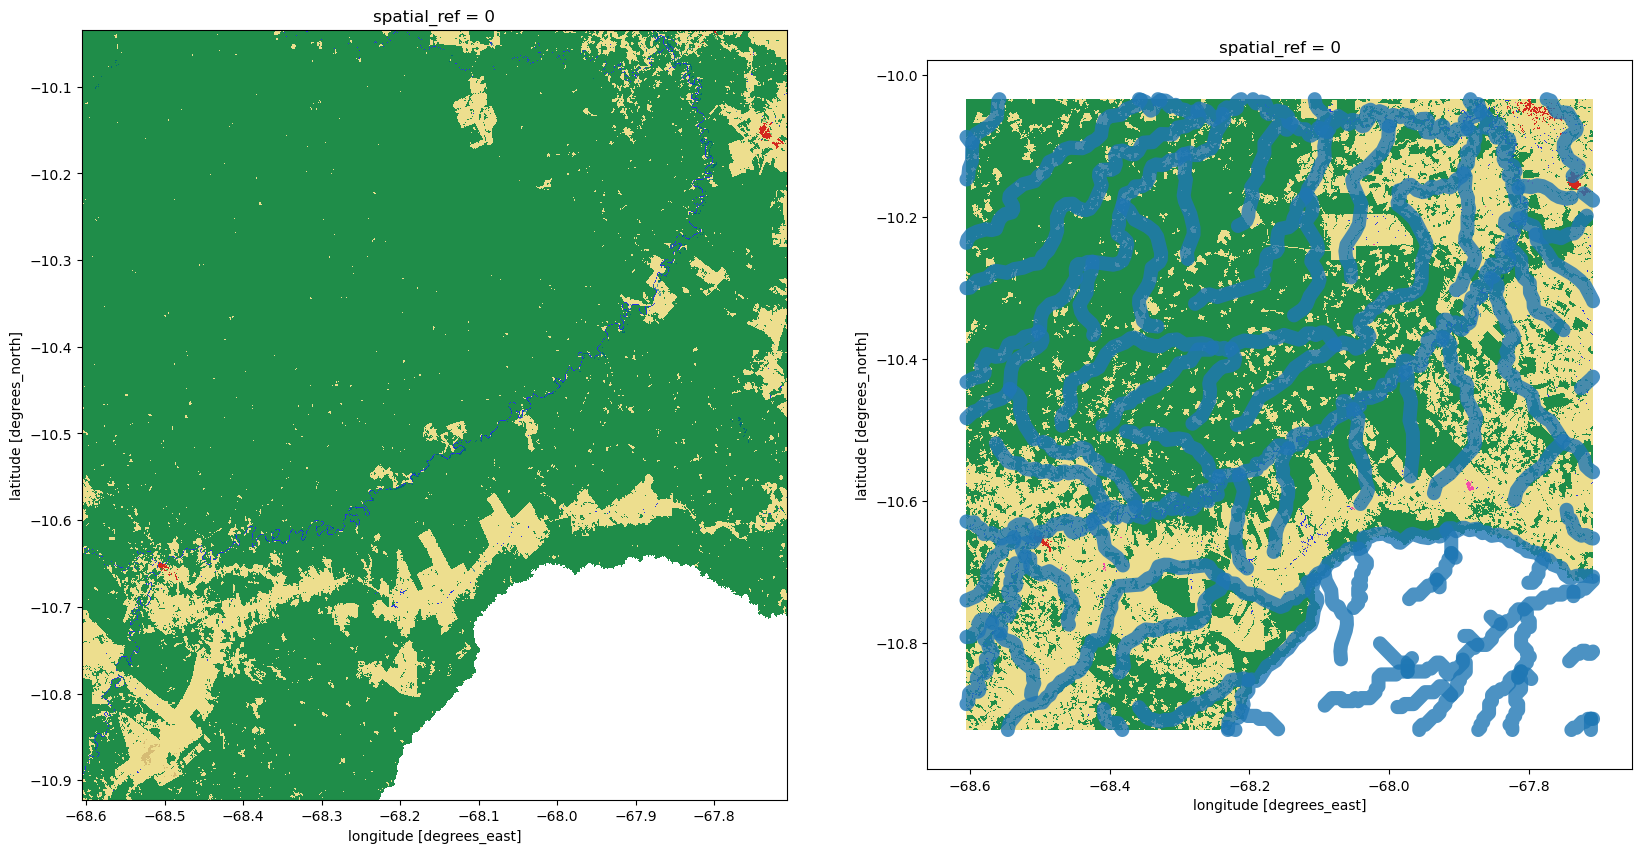

In [125]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize = (20, 10))
lclu_1985_subset_stylized.plot.imshow(ax = ax[0])
lclu_2022_subset_stylized.plot.imshow(ax = ax[1])
rivers_subset.buffer(.01).plot(ax = ax[1], alpha=.8)

In [151]:
rivers_subset.dissolve().geometry

0    MULTIPOLYGON (((-68.38782 -10.91175, -68.38773...
Name: geometry, dtype: geometry

In [ ]:
lclu_1985.rio.clip(rivers_subset.dissolve().geometry)

In [89]:
change_map = lclu_1985.isin([1,3,4,5,6,49])
change_map = xr.where((change_map & (~lclu_2022.isin([1,3,4,5,6,49]))), 2, change_map).rio.write_crs(4326).rio.write_coordinate_system()

In [82]:
cell_exterior = grid_data.to_crs(4326).iloc[[i]].exterior.iloc[0].xy

In [91]:
test = change_map.rio.clip_box(cell_exterior[0][2], cell_exterior[1][1], cell_exterior[0][1], cell_exterior[1][0])

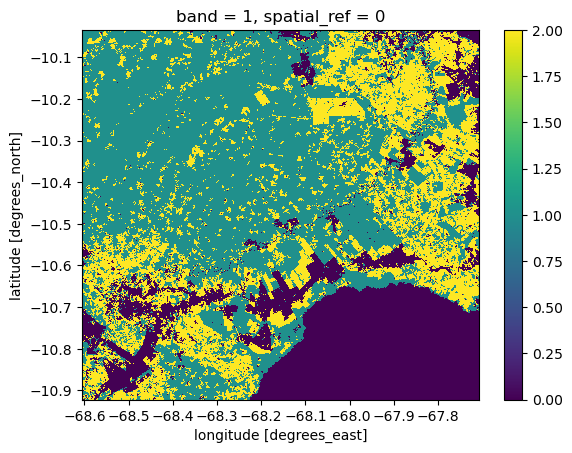

In [96]:
test.sel(band=1).plot.imshow(vmin = 0, vmax = 2)

In [ ]:
cell = grid_data.iloc[[i]]

lc_glc_combined.sel(
    dict(x = np.arange(cell_exterior[0][2] - 1, cell_exterior[0][1] + 1, 0.00025),
         y = np.arange(cell_exterior[1][1] - 1, cell_exterior[1][0] + 1, 0.00025)), 
    method = "nearest").load()


### Probav LC100

In [ ]:
# viewer: https://land.copernicus.eu/global/lcviewer
# data: https://zenodo.org/record/3939038#.ZEY84i-21qs

In [2]:
import xarray as xr
import rioxarray as rxr
import numpy as np

In [2]:
cloud_dist = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Master Thesis/data/imagery/landsat/Landsat 4-5 TM Collection 2 Level-2/LT05_L2SP_175084_19840609_20200918_02_T1/LT05_L2SP_175084_19840609_20200918_02_T1_ST_CDIST.TIF")

In [6]:
land_cover = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Master Thesis/data/land cover/PROBAV_LC100_global_v3.0.1_2015-base_Discrete-Classification-map_EPSG-4326.tif")

In [17]:
land_cover_sample = land_cover.squeeze().rio.clip_box(*cloud_dist.rio.reproject("EPSG:4326").rio.bounds())

In [23]:
np.unique(land_cover_sample, return_counts = True)

(array([ 20,  30,  40,  50,  60,  80,  90, 112, 114, 115, 116, 122, 124,
        125, 126, 200], dtype=uint8),
 array([ 135584,  542080,  214011,   69897,     537,   14861,    5683,
           1597,     930,       6,   10442,       2,      72,       1,
          31826, 4080041]))

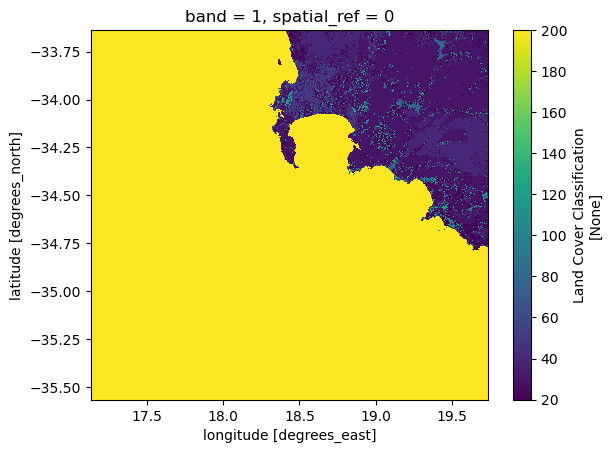

In [16]:
land_cover.squeeze().rio.clip_box(*cloud_dist.rio.reproject("EPSG:4326").rio.bounds()).plot.imshow()

### IBGE LC 30

In [ ]:
import sqlite3
import numpy as np
import pandas as pd
import geopandas as gpd

import xarray as xr
import rioxarray as rxr
import shapely

from tqdm import tqdm

from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_points_griddata

In [ ]:
land_cover = gpd.read_file("/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Uni/Masterthesis/data/land_cover/Cobertura_uso_terra_Brasil_serie_revisada/Cobertura_uso_terra_Brasil_serie_revisada.shp")

KeyboardInterrupt: 

In [ ]:
land_cover.set_index("REFNAME", inplace = True)

In [ ]:
land_cover

,TEXT,DESCRIèãO,AREA,refn_descr,geometry
REFNAME,,,,,
AC_1.1.7398,AC_1.1.7398,Cidades,1.1033,AC_1.1.7398_Cidades,"POLYGON ((-67.67806 -10.58283, -67.67833 -10.5..."
AC_1.1.7398,AC_1.1.7398,Cidades,0.6579,AC_1.1.7398_Cidades,"POLYGON ((-69.55851 -10.93654, -69.55823 -10.9..."
AC_1.1.7398,AC_1.1.7398,Cidades,3.0128,AC_1.1.7398_Cidades,"POLYGON ((-68.75963 -10.98607, -68.75868 -10.9..."
AC_1.1.7398,AC_1.1.7398,Cidades,0.0036,AC_1.1.7398_Cidades,"POLYGON ((-70.04697 -10.97985, -70.04752 -10.9..."
AC_1.1.7398,AC_1.1.7398,Cidades,0.1215,AC_1.1.7398_Cidades,"POLYGON ((-70.04540 -10.98366, -70.04539 -10.9..."
...,...,...,...,...,...
AC_2.3.1,AC_2.3.1,Pecuária de animais de grande porte,0.1100,AC_2.3.1_Pecuária de animais de grande porte,"POLYGON ((-70.28406 -8.06527, -70.28406 -8.065..."
AC_2.3.1,AC_2.3.1,Pecuária de animais de grande porte,0.0475,AC_2.3.1_Pecuária de animais de grande porte,"POLYGON ((-70.28462 -8.06600, -70.28554 -8.066..."
AC_2.3.1,AC_2.3.1,Pecuária de animais de grande porte,0.0850,AC_2.3.1_Pecuária de animais de grande porte,"POLYGON ((-70.28302 -8.06814, -70.28357 -8.068..."


In [ ]:
land_cover["DESCRIèãO"].unique()

array(['Cidades',
       'Cultivos temporários diversificados  + Pecuária animais de pequeno porte  + Extrativismo animal em área florestal',
       'Outros cultivos permanentes',
       'Pecuária de animais de grande porte',
       'Pecuária de animais de grande porte + Cultivos temporários diversificados',
       'Unidades de conservação de proteção integral em área florestal + Pecuária de animais de grande porte + Cultivos tempor',
       'Unidades de conservação de proteção integral em área florestal',
       'Unidades de conservação de uso sustentável  em área florestal',
       'Unidades de conservação de uso sustentável em área florestal + Cultivo agroflorestal',
       'Extrativismo vegetal em área florestal + Extrativismo animal em área florestal',
       'Extrativismo vegetal em área florestal + Cultivos temporários diversificados',
       'Frutíferas permanentes', 'Terra indígena em área florestal',
       'Aquicultura em corpo d\x92água continental',
       'Terra indígena 

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (20, 20))
land_cover.plot(column = "DESCRIèãO", ax = ax)

In [ ]:
# connect to database
conn = sqlite3.connect('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/imagery.db')
# get grid data
grid_data = pd.read_sql_query("SELECT * FROM GridCells WHERE Internal=1", conn)
# get grid geometries
grid_geoms = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/grid_cells.feather")
# merge data
grid_data = gpd.GeoDataFrame(grid_data.merge(grid_geoms, on = "CellID"))
# close connection
conn.close()

In [ ]:
# get land cover shapefile
lc = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/Cobertura_uso_terra_Brasil_serie_revisada.feather")

In [ ]:
# vectorize land cover grid-wise
for i in tqdm([50]):#range(len(grid_data))
    # get grid cell
    cell = grid_data.iloc[[i]]
    # get land cover data
    lc_data = lc.loc[lc.intersects(cell.geometry.iloc[0]), :]
    
    bbox = gpd.GeoSeries(shapely.geometry.box(*cell.total_bounds), crs="EPSG:5641")
    geom = bbox.__geo_interface__["features"][0]["geometry"]
    geom["crs"] = {"properties": {"name": "EPSG:5641"}}
    
    # create xarray
    lc_xr = make_geocube(
        vector_data = lc_data,
        measurements = [f"USO{t}" for t in [2000, 2010, 2012, 2014, 2016, 2018, 2020]],
        output_crs = "EPSG:5641",
        fill = -1,
        geom = geom,
        align = (0, 0),
        resolution = [-30, 30]
    )
    lc_xr = lc_xr.astype(np.uint8, copy = False)
    
    # save to file
    #lc_xr.rio.to_raster(f"/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/grid/ibge_{cell.CellID.iloc[0]}.tif")

100%|██████████| 1/1 [00:03<00:00,  3.06s/it]


In [ ]:
lc_xr

<xarray.Dataset> Size: 78MB
Dimensions:      (y: 3328, x: 3328)
Coordinates:
  * y            (y) float64 27kB 1.018e+07 1.018e+07 ... 1.008e+07 1.008e+07
  * x            (x) float64 27kB 2.451e+06 2.451e+06 ... 2.551e+06 2.551e+06
    spatial_ref  int64 8B 0
Data variables:
    USO2000      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6
    USO2010      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6
    USO2012      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6
    USO2014      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6
    USO2016      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6
    USO2018      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6
    USO2020      (y, x) uint8 11MB 255 255 255 255 255 255 255 ... 6 6 6 6 6 6 6

In [ ]:
rxr.open_rasterio("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/grid/ibge_213.tif")

<xarray.DataArray (band: 7, y: 3328, x: 3328)> Size: 78MB
[77529088 values with dtype=int8]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 27kB 2.451e+06 2.451e+06 ... 2.551e+06 2.551e+06
  * y            (y) float64 27kB 1.018e+07 1.018e+07 ... 1.008e+07 1.008e+07
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    long_name:      ('USO2000', 'USO2010', 'USO2012', 'USO2014', 'USO2016', '...
    name:           USO2000
    _FillValue:     -1
    scale_factor:   1.0
    add_offset:     0.0

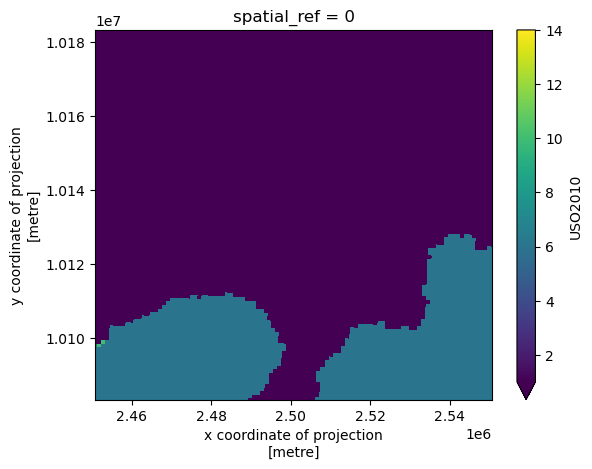

In [ ]:
lc_xr.USO2010.plot.imshow(vmin = 1, vmax = 14)

### ESA CCI 300

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

import xarray as xr
import rioxarray as rxr

In [ ]:
boundaries = gpd.read_file("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/boundaries/gadm_410-BRA.geojson",
                           engine = "pyogrio")

In [ ]:
lc_esacci_300 = rxr.open_rasterio("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/scratch/ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992_2015-v2.0.7.tif",
                                  chunks = True)

In [ ]:
lc_esacci_300_2010_crop = lc_esacci_300.sel(band=(2010 - 1991)).rio.clip([boundaries.geometry.iloc[0]])

In [ ]:
lc_esacci_300_2010_crop.drop_vars("band").rio.to_raster("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/scratch/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2010-v2.0.7.tif")

In [ ]:
lc_esacci_300_2010_crop.load()

<xarray.DataArray (y: 14044, x: 16250)> Size: 228MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
Coordinates:
    band         int64 8B 19
  * x            (x) float64 130kB -73.99 -73.98 -73.98 ... -28.86 -28.85 -28.85
  * y            (y) float64 112kB 5.262 5.26 5.257 ... -33.74 -33.74 -33.75
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0

In [ ]:
np.unique(lc_esacci_300_2010_crop)

array([  0,  10,  11,  12,  20,  30,  40,  50,  60,  61,  62,  70,  80,
        90, 100, 110, 120, 130, 150, 153, 160, 170, 180, 190, 200, 210],
      dtype=uint8)

In [ ]:
lc_esacci_300_2010_crop.rio.reproject("EPSG:5641")

<xarray.DataArray (y: 14423, x: 15914)> Size: 230MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
Coordinates:
  * x            (x) float64 127kB 1.553e+06 1.553e+06 ... 6.574e+06 6.574e+06
  * y            (y) float64 115kB 1.058e+07 1.058e+07 ... 6.032e+06 6.031e+06
    band         int64 8B 19
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0

#### Potapov et al. (2022) - Global 30m

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import sqlite3

import xarray as xr
import rioxarray as rxr

In [ ]:
fetch_instructions = pd.read_json("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/setup/fetch.json")
def get_fetch_instructions(id):
    return fetch_instructions[fetch_instructions["id"] == id].to_dict(orient = "records")[0]

In [ ]:
for f in get_fetch_instructions("lc_glc_30")["url"]["files"]:
    rxr.open_rasterio(f"/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/{f}", chunks = True).\
        rio.reproject("EPSG:4326").\
        rio.to_raster(f"/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/{f}")

In [ ]:
shapefiles = [rxr.open_rasterio(f"/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/{f}", chunks = True) for f in get_fetch_instructions("lc_glc_30")["url"]["files"]]

In [ ]:
shapefiles_combined = xr.combine_by_coords(shapefiles).sel(band = 1)

In [ ]:
shapefiles_combined

<xarray.DataArray (y: 200000, x: 200000)> Size: 160GB
dask.array<getitem, shape=(200000, 200000), dtype=float32, chunksize=(3355, 40000), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 2MB -80.0 -80.0 -80.0 -80.0 ... -30.0 -30.0 -30.0
  * y            (y) float64 2MB 10.0 10.0 9.999 9.999 ... -40.0 -40.0 -40.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [ ]:
cell = grid_data.to_crs(4326).iloc[[0]]
cell_exterior = cell.exterior.iloc[0].coords.xy

In [ ]:
cell_exterior

(array('d', [-61.42602898470794, -61.42602898470794, -62.32318033485499, -62.32318033485499, -61.42602898470794]),
 array('d', [5.264839452374542, 4.364880981938602, 4.364880981938602, 5.264839452374542, 5.264839452374542]))

In [ ]:
shapefiles_combined_subset = shapefiles_combined.sel(
    dict(x = np.arange(cell_exterior[0][2] - 1, cell_exterior[0][1] + 1, 0.00025),
         y = np.arange(cell_exterior[1][1] - 1, cell_exterior[1][0] + 1, 0.00025)), 
    method = "nearest").load()

In [ ]:
test = shapefiles_combined_subset.rio.reproject("EPSG:5641").reindex_like(lc_xr, method = "nearest")

In [ ]:
np.unique(test)

array([48.], dtype=float32)

In [ ]:
np.arange(min(cell_exterior[0]), max(cell_exterior[0]) + 30, 30)

array([2850255., 2850285., 2850315., ..., 2950005., 2950035., 2950065.])

In [ ]:
np.arange(min(cell_exterior[1]), max(cell_exterior[1]) + 30, 30)

array([10482825., 10482855., 10482885., ..., 10582575., 10582605.,
       10582635.])

In [ ]:
shapefiles_combined = shapefiles_combined.rio.clip([grid_data.iloc[0].geometry])

: 

: 

### Crops

In [ ]:
import numpy as np
import xarray as xr
import rioxarray as rxr

import sqlite3
import pandas as pd
import geopandas as gpd

In [ ]:
from cropharvest.datasets import CropHarvest

In [ ]:
boundaries = gpd.read_file("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/boundaries/gadm_410-BRA.geojson",
                           engine = "pyogrio")

In [ ]:
test = gpd.read_file("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/test/crop_harvest/labels.geojson", engine = "pyogrio")

In [ ]:
test = gpd.clip(test, boundaries.geometry.iloc[0])

<Axes: >

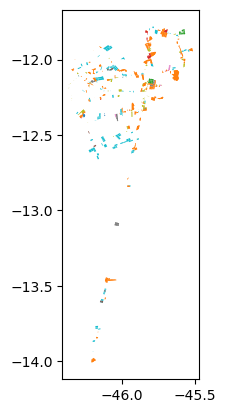

In [ ]:
test.plot(column = "label")

In [ ]:
CropHarvest.create_benchmark_datasets("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/test/crop_harvest")

67651584it [00:02, 24010770.09it/s]                              
782628864it [01:13, 10716367.02it/s]                               
70582272it [00:02, 28700305.31it/s]                              


[CropHarvestEval(Kenya_1_maize, Kenya_maize),
 CropHarvestEval(Brazil_0_coffee, Brazil_coffee),
 CropHarvestEval(Togo_crop, togo-eval)]

---
## Auxiliary Data
### Biome Clusters

In [5]:
import geopandas as gpd

In [8]:
# biome clusters
# see https://zenodo.org/record/5848610#.ZEZ4Py-21qs
biome_clusters = gpd.read_file("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Master Thesis/data/biome clusters/biome_cluster_shapefile/ProbaV_UTM_LC100_biome_clusters_V3_global.shp")

<Axes: >

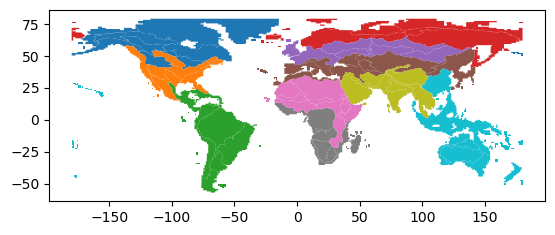

In [14]:
biome_clusters.plot(column = "bc_id")

### Elevation

In [15]:
import xarray as xr
import rioxarray as rxr

In [17]:
# https://www.usgs.gov/centers/eros/science/usgs-eros-archive-digital-elevation-shuttle-radar-topography-mission-srtm-1
elevation = rxr.open_rasterio("/Users/felixschulz/Library/CloudStorage/OneDrive-Persönlich/Dokumente/Uni/Master Thesis/data/DTM/srtm_40_19/srtm_40_19.tif")

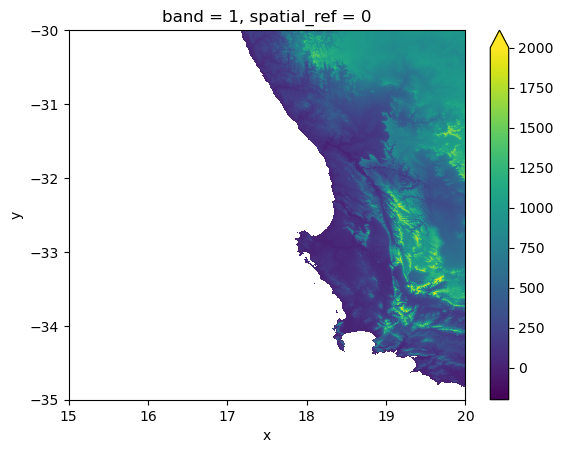

In [20]:
elevation.where(elevation >= -200).squeeze().plot.imshow(vmin = -200, vmax = 2000)

### Seasonality (Wet seasons)

In [ ]:
import urllib.request
urllib.request.urlretrieve('ftp://cola.gmu.edu/RADS/TRMM/median.onset.wet.season.TRMM.nc', "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/test/median.onset.wet.season.TRMM.nc")
urllib.request.urlretrieve('ftp://cola.gmu.edu/RADS/TRMM/median.total.precip.dry.season.TRMM.nc', "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/test/median.total.precip.dry.season.TRMM.nc")

('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/test/median.total.precip.dry.season.TRMM.nc',
 <email.message.Message at 0x14cf2dddce80>)

In [ ]:
# connect to database
conn = sqlite3.connect('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/imagery.db')
# get grid data
grid_data = pd.read_sql_query("SELECT * FROM GridCells WHERE Internal=1", conn)
# get grid geometries
grid_geoms = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/grid_cells.feather")
# merge data
grid_data = gpd.GeoDataFrame(grid_data.merge(grid_geoms, on = "CellID"))
# close connection
conn.close()

In [ ]:
boundaries = gpd.read_file("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/boundaries/gadm_410-BRA.geojson",
                           engine = "pyogrio")

In [ ]:
wet_season_onset = xr.open_dataset("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/test/median.onset.wet.season.TRMM.nc", decode_times=False).to_dataarray().sel(time=0, lev=1000, variable="medons")
wet_season_onset["lon"] = (((wet_season_onset["lon"] // 180) * (- 360)) + wet_season_onset["lon"])
wet_season_onset = wet_season_onset.sortby("lon").rio.write_crs(4326).rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True).rio.write_coordinate_system()

<Axes: title={'center': 'time = 0 [years since 1979-01-01 00:00], lev = ...'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

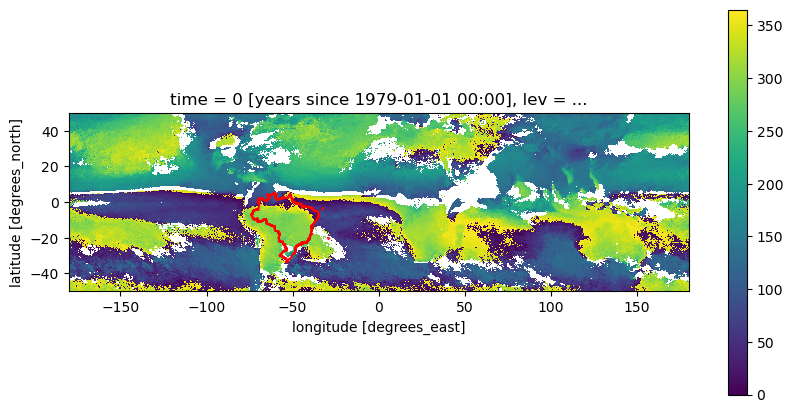

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
wet_season_onset.plot.imshow(ax = ax)
boundaries.boundary.plot(ax = ax, color = "red")

In [ ]:
test = wet_season_onset.rio.clip([boundaries.geometry.iloc[0]], drop = True)

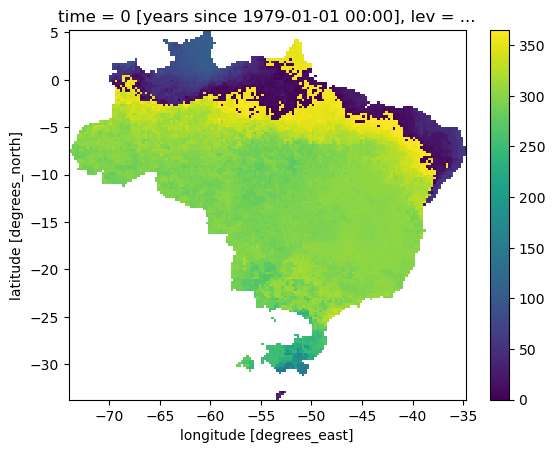

In [ ]:
test.plot.imshow()

---
# Combining Data

In [2]:
import io
import sqlite3

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.io import MemoryFile
from geocube.api.core import make_geocube

from google.cloud import storage

In [3]:
# connect to database
conn = sqlite3.connect('/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/imagery.db')
# get grid data
grid_data = pd.read_sql_query("SELECT * FROM GridCells WHERE Internal=1", conn)
# get grid geometries
grid_geoms = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/imagery/grid_cells.feather")
# merge data
grid_data = gpd.GeoDataFrame(grid_data.merge(grid_geoms, on = "CellID"))
# close connection
conn.close()

<Axes: >

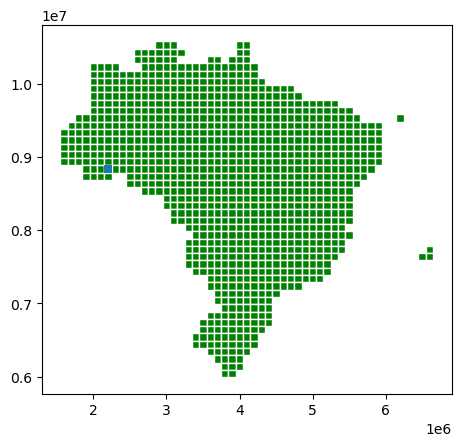

In [4]:
ax = grid_data.plot(edgecolor="white", color = grid_data.Internal.map({1: "green", 0: "red"}))
grid_data[((grid_data.Row == 17) & (grid_data.Column == 6))].plot(ax = ax)

In [5]:
# Initialize the GCS client
client = storage.Client("master-thesis-414809")

# Get the bucket
bucket = client.get_bucket("master-thesis-lulc")

# List files in the bucket
blobs = np.array(list(bucket.list_blobs()))

# Extract file names
file_names = np.array([blob.name for blob in blobs])

In [6]:
i = 525

In [7]:
cell = grid_data.iloc[[i]]

#
def get_grid_name(cell):
    return "mapbiomas/2010_{:010d}-{:010d}.tif".format(*(cell[["Row", "Column"]].to_numpy() * 3328)[0])

# Download a .tif file as bytes
file_bytes = blobs[(file_names == get_grid_name(cell))][0].download_as_string()

# Create a virtual file-like object
virtual_file = io.BytesIO(file_bytes)

# Open the virtual file as a rasterio dataset
with rasterio.open(virtual_file) as dataset:
    imagery = rxr.open_rasterio(virtual_file)

In [10]:
# get land cover shapefile
lc_ibge = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/lc_ibge_30_2010.feather")

In [11]:
# get land cover data
lc_ibge_data = lc_ibge.loc[lc_ibge.intersects(cell.geometry.iloc[0]), :]

#
bbox = gpd.GeoSeries(shapely.geometry.box(*cell.total_bounds), crs="EPSG:5641")
geom = bbox.__geo_interface__["features"][0]["geometry"]
geom["crs"] = {"properties": {"name": "EPSG:5641"}}

# create xarray
out = make_geocube(
    vector_data = lc_ibge_data,
    measurements = ["GRIDCODE"],
    output_crs = "EPSG:5641",
    fill = 65535,
    geom = geom,
    align = (0, 0),
    resolution = [-30, 30]
)

In [12]:
out = xr.concat([imagery, out.GRIDCODE.assign_coords({"band": 7})], dim="band")
out.attrs["long_name"] += tuple(["lc_ibge"])

In [13]:
fetch_instructions = pd.read_json("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/setup/fetch.json")
def get_fetch_instructions(id):
    return fetch_instructions[fetch_instructions["id"] == id].to_dict(orient = "records")[0]

In [15]:
lc_glc_list = [rxr.open_rasterio(f"/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/raw/lc_glc_30/{f}", chunks = True) for f in get_fetch_instructions("lc_glc_30")["url"]["files"]]
lc_glc_combined = xr.combine_by_coords(lc_glc_list).sel(band = 1)

In [16]:
cell_exterior = cell.to_crs(4326).exterior.iloc[0].coords.xy

In [17]:
lc_glc_combined_subset = lc_glc_combined.sel(
    dict(x = np.arange(cell_exterior[0][2] - 1, cell_exterior[0][1] + 1, 0.00025),
         y = np.arange(cell_exterior[1][1] - 1, cell_exterior[1][0] + 1, 0.00025)), 
    method = "nearest").load()

In [18]:
out = xr.concat([out, lc_glc_combined_subset.rio.reproject("EPSG:5641").reindex_like(out, method = "nearest").assign_coords({"band": 8})], dim="band")
out.attrs["long_name"] += tuple(["lc_glc"])
out = out.astype(np.uint16, copy = False)

In [19]:
def parse_legend(legend):
    """
    Parses legend strings to generate a list of integers for ranges and individual elements.

    Args:
    legend (list or str): List of legend strings or a single legend string.

    Returns:
    list or str: Parsed legend as a list of integers or a single string.
    """

    # Initialize parsed legend list
    parsed_legend = []

    # Check if legend is a list
    if isinstance(legend, str):
        # Iterate through each legend string
        for x in legend.split(","):
            # Check if ":" is present in the legend string
            if ":" in x:
                # Split the legend string at ":" and convert split parts to integers
                start, end = map(int, x.split(":"))
                # Extend parsed legend with range of values between start and end (inclusive)
                parsed_legend.extend(range(start, end + 1))
            else:
                # Append the element directly to parsed legend
                parsed_legend.append(int(x))
        # Return parsed legend as a list of integers
        return parsed_legend
    else:
        # Return the legend string if it is not a list
        return legend

In [20]:
def validate_entries(x, y, correspondence_table):
    """
    Validates entries of matrix X against matrix Y using a correspondence table.
    
    Parameters:
    - x (xr.DataArray): Input data array X.
    - y (xr.DataArray): Input data array Y.
    - correspondence_table (dict): A dictionary where keys are possible values from X 
      and values are lists of corresponding acceptable values in Y.
    
    Returns:
    - xr.DataArray: A boolean data array where True indicates a valid correspondence 
      between X and Y entries according to the correspondence table, and False otherwise.
    """
    
    # Initialize an empty data array with the same shape as X and Y, filled with False
    valid_mask = xr.full_like(x, False, dtype=bool)
    
    # Iterate through the correspondence table to update the valid_mask
    for x_val, y_vals in correspondence_table.items():
        # For each value in X, check if the corresponding value in Y is in the list of acceptable values
        mask = x == x_val
        for y_val in y_vals:
            valid_mask = xr.where(mask & (y == y_val), True, valid_mask)
            
    return valid_mask

In [21]:
validation_legend = pd.read_excel("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/legend/validation_legend.xlsx")
validation_legend = validation_legend.iloc[:-1].loc[:,["Level 1", "IBGE", "GLC"]]
validation_legend["GLC"] = validation_legend.GLC.map(parse_legend)
validation_legend["IBGE"] = validation_legend.IBGE.map(parse_legend)
validation_legend = validation_legend.explode("IBGE").explode("GLC").dropna().drop_duplicates()#.groupby("IBGE").GLC.apply(lambda x: x.tolist())
validation_legend["IBGE"] = validation_legend.IBGE.astype(np.int8)
validation_legend = validation_legend.groupby("IBGE").GLC.apply(lambda x: list(sorted(x.tolist()))).to_dict()

test = xr.where(out.sel(band=7).isin([0,10,11]), np.nan, validate_entries(out.sel(band=7), out.sel(band=8), validation_legend))

In [22]:
def stylize_map(x, legend):
    if isinstance(legend, dict):
        value_color_dict = legend
    if isinstance(legend, str):
        lc_glc_legend = pd.read_excel(legend).dropna(subset = ["Color code"])
        value_color_dict = {x["Map value"]: tuple(int(str(x["Color code"])[i:i+2], 16) for i in (0, 2, 4)) for x in lc_glc_legend[["Map value", "Color code"]].to_dict(orient="records")}

    # Create an empty image
    colormap_image = xr.full_like(x, 255, dtype=np.uint8)
    colormap_image = colormap_image.expand_dims({"band": [1,2,3]})

    # Populate the image with colors from the dictionary
    for value, color in value_color_dict.items():
        colormap_image = xr.where(x == value, color, colormap_image)
        
    return colormap_image

lc_glc_plot_ready = stylize_map(out.sel(band=8), "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/land_cover/legend/glc_legend.xlsx")

In [23]:
lc_ibge_plot_ready = stylize_map(out.sel(band=7), 
                                {1: (255, 0, 0), 2: (235, 230, 50),
                                3: (205, 137, 0), 4: (212, 232, 133),
                                5: (0, 144, 89), 6: (115, 168, 0),
                                7: (146, 214, 0), 8: (200, 145, 170),
                                9: (190, 185, 245), 10: (206, 180, 100),
                                11: (215, 153, 100), 12: (140, 255, 255),
                                13: (210, 250, 255), 14: (136, 136, 136)})

In [24]:
rivers = gpd.read_feather("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/misc/msc_rivers.feather").to_crs(5641)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


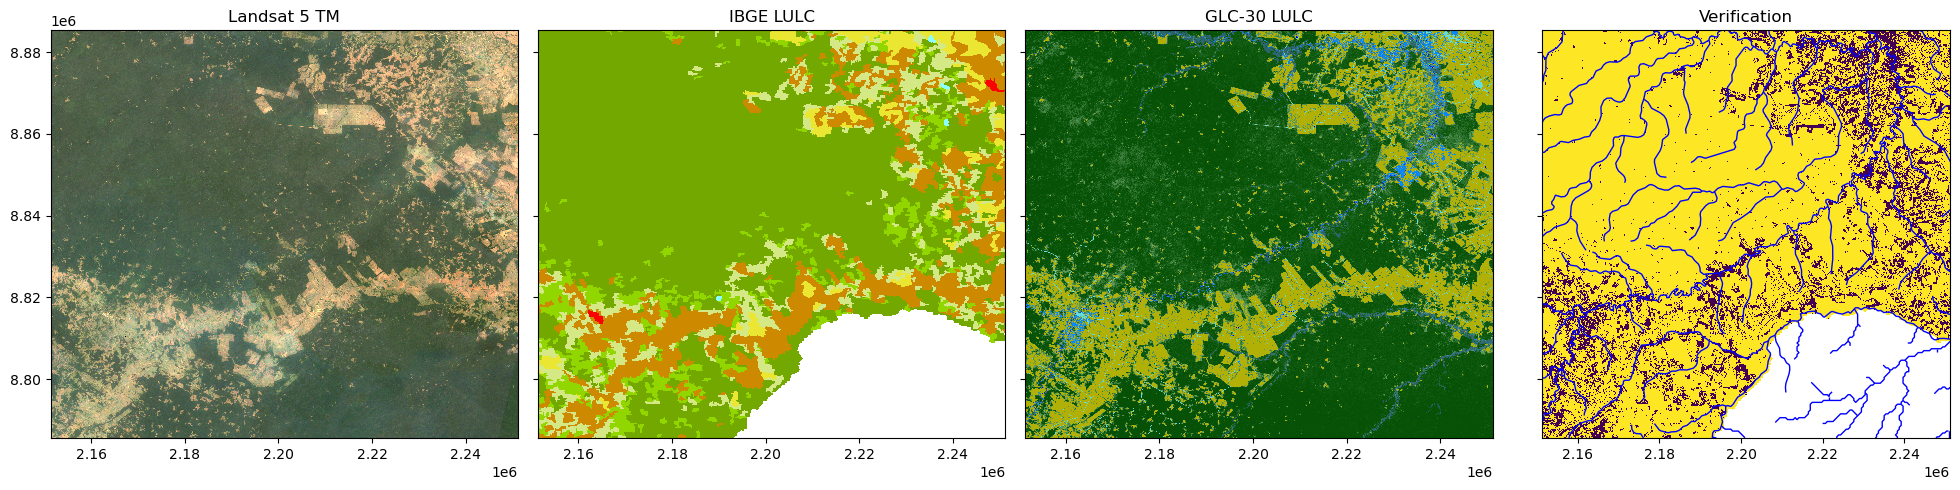

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

(out.sel(band=[3,2,1]) * .2).astype(np.uint16).plot.imshow(ax = ax[0], add_labels = False)
ax[0].set_title("Landsat 5 TM")

(lc_ibge_plot_ready).plot.imshow(ax = ax[1], add_colorbar = False, add_labels = False)
ax[1].set_title("IBGE LULC")

lc_glc_plot_ready.plot.imshow(ax = ax[2], add_colorbar = False, add_labels = False)
ax[2].set_title("GLC-30 LULC")

test.plot.imshow(ax = ax[3], add_colorbar = False, add_labels = False)
gpd.clip(rivers, cell).plot(ax = ax[3], color = "blue", linewidth = 1)
ax[3].set_title("Verification")

fig.tight_layout()
fig.savefig("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/output/figures/verification.png", dpi = 300)
fig.show()